In [1]:
%matplotlib inline

import numpy as np
import torch as tc
import matplotlib.pyplot as plt

In [2]:
train_dir = '/kaggle/input/butterfly-images40-species/train'
val_dir = '/kaggle/input/butterfly-images40-species/valid'
test_dir = '/kaggle/input/butterfly-images40-species/test'

In [3]:
from torchvision import datasets, transforms

mean = tc.Tensor([0.485, 0.456, 0.406])
std = tc.Tensor([0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=test_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

print("Number of training samples:", len(train_dataset))
print("Number of validation samples:", len(val_dataset))
print("Number of testing samples:", len(test_dataset))

print("Number of classes:", len(train_dataset.classes))

Number of training samples: 12594
Number of validation samples: 500
Number of testing samples: 500
Number of classes: 100


In [4]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, num_workers=4)

In [5]:
def imshow(img):
    img = img * std.unsqueeze(1).unsqueeze(2) + mean.unsqueeze(1).unsqueeze(2)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

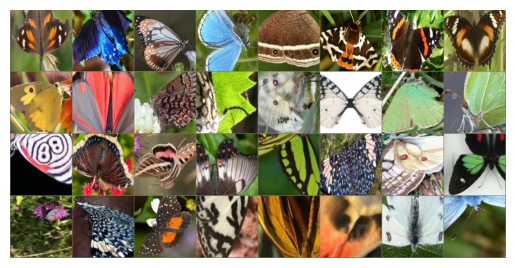

AMERICAN SNOOT, PIPEVINE SWALLOW, CHESTNUT, ADONIS, MESTRA, GARDEN TIGER MOTH, RED ADMIRAL, GREAT EGGFLY, SOUTHERN DOGFACE, CINNABAR MOTH, EASTERN PINE ELFIN, GIANT LEOPARD MOTH, CLODIUS PARNASSIAN, CLODIUS PARNASSIAN, GREEN HAIRSTREAK, CLEOPATRA, AN 88, MOURNING CLOAK, WHITE LINED SPHINX MOTH, ORCHARD SWALLOW, MALACHITE, RED CRACKER, CLODIUS PARNASSIAN, GREEN CELLED CATTLEHEART, SIXSPOT BURNET MOTH, RED CRACKER, CRIMSON PATCH, ELBOWED PIERROT, BANDED ORANGE HELICONIAN, BANDED TIGER MOTH, BECKERS WHITE, CHALK HILL BLUE


In [6]:
from torchvision.utils import make_grid

images, labels = next(iter(train_loader))
imshow(make_grid(images))
print(', '.join(f'{train_loader.dataset.classes[labels[i]]}' for i in range(len(labels))))

In [7]:
import torch.nn as nn
import torch.nn.init as init

model = tc.hub.load('facebookresearch/deit:main', 'deit_tiny_patch16_224', pretrained=True)

for param in model.parameters():
    param.requires_grad = False

num_inputs = model.head.in_features

model.head = nn.Sequential(
    nn.Linear(num_inputs, 1024),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(1024, len(train_dataset.classes))
)

for layer in model.head:
    if isinstance(layer, nn.Linear):
        init.xavier_normal_(layer.weight)

model = model.cuda()

Downloading: "https://github.com/facebookresearch/deit/zipball/main" to /root/.cache/torch/hub/main.zip
/usr/local/lib/python3.10/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.10/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/root/.cache/torch/hub/facebookresearch_deit_main/models.py:63: UserWarning: Overwriting deit_tiny_patch16_224 in registry with models.deit_tiny_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  def deit_tiny_patch16_224(pretrained=False, **kwargs):
/root/.cache/torch/hub/f

In [8]:
import torch.optim as optim
from torchsummary import summary
from timm.loss import LabelSmoothingCrossEntropy

criterion = LabelSmoothingCrossEntropy().cuda()
optimizer = optim.RAdam(model.head.parameters(), lr=1e-3, weight_decay=1e-6,
                        decoupled_weight_decay=True, foreach=True)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 192, 14, 14]         147,648
          Identity-2             [-1, 196, 192]               0
        PatchEmbed-3             [-1, 196, 192]               0
           Dropout-4             [-1, 197, 192]               0
          Identity-5             [-1, 197, 192]               0
          Identity-6             [-1, 197, 192]               0
         LayerNorm-7             [-1, 197, 192]             384
            Linear-8             [-1, 197, 576]         111,168
          Identity-9           [-1, 3, 197, 64]               0
         Identity-10           [-1, 3, 197, 64]               0
           Linear-11             [-1, 197, 192]          37,056
          Dropout-12             [-1, 197, 192]               0
        Attention-13             [-1, 197, 192]               0
         Identity-14             [-1, 1

In [9]:
import time

num_epochs = 30

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):
    epoch_train_loss = 0
    epoch_val_loss = 0
    epoch_train_corrects = 0
    epoch_val_corrects = 0

    model.train()
    for inputs, targets in train_loader:
        inputs, targets = inputs.cuda(), targets.cuda()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        preds = tc.argmax(outputs, dim=1)
        
        loss = criterion(outputs, targets)
        epoch_train_loss += loss.item() * inputs.size(0)
        epoch_train_corrects += tc.sum(preds == targets.data).float()

        loss.backward()
        optimizer.step()

    scheduler.step()

    epoch_train_loss /= len(train_dataset)
    epoch_train_accuracy = epoch_train_corrects / len(train_dataset)
    
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy.cpu())

    model.eval()
    with tc.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.cuda(), targets.cuda()
            
            val_outputs = model(inputs)
            
            val_preds = tc.argmax(val_outputs, dim=1)
            
            val_loss = criterion(val_outputs, targets)
            epoch_val_loss += val_loss.item() * inputs.size(0)
            epoch_val_corrects += tc.sum(val_preds == targets.data).float()

    epoch_val_loss /= len(test_dataset)
    epoch_val_accuracy = epoch_val_corrects / len(test_dataset)
    
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy.cpu())

    print("Epoch {}/{}: Train Loss = {:.4f}, Val Loss = {:.4f}, Train Acc = {:.4f}, Val Acc = {:.4f}".format(
        epoch + 1, num_epochs, train_losses[-1], val_losses[-1], train_accuracies[-1], val_accuracies[-1]))

end_time = time.time()
training_time = end_time - start_time

print("Training time: {:.2f}s".format(training_time))

Epoch 1/30: Train Loss = 3.0191, Val Loss = 1.6750, Train Acc = 0.4013, Val Acc = 0.7740
Epoch 2/30: Train Loss = 1.7932, Val Loss = 1.3930, Train Acc = 0.7141, Val Acc = 0.8600
Epoch 3/30: Train Loss = 1.6252, Val Loss = 1.3196, Train Acc = 0.7778, Val Acc = 0.8800
Epoch 4/30: Train Loss = 1.5427, Val Loss = 1.2955, Train Acc = 0.8038, Val Acc = 0.8880
Epoch 5/30: Train Loss = 1.5047, Val Loss = 1.2637, Train Acc = 0.8121, Val Acc = 0.9060
Epoch 6/30: Train Loss = 1.4665, Val Loss = 1.2176, Train Acc = 0.8263, Val Acc = 0.9120
Epoch 7/30: Train Loss = 1.4418, Val Loss = 1.2592, Train Acc = 0.8334, Val Acc = 0.8820
Epoch 8/30: Train Loss = 1.4126, Val Loss = 1.2024, Train Acc = 0.8475, Val Acc = 0.9140
Epoch 9/30: Train Loss = 1.4015, Val Loss = 1.1938, Train Acc = 0.8493, Val Acc = 0.9160
Epoch 10/30: Train Loss = 1.3636, Val Loss = 1.2050, Train Acc = 0.8618, Val Acc = 0.9140
Epoch 11/30: Train Loss = 1.3596, Val Loss = 1.1702, Train Acc = 0.8629, Val Acc = 0.9300
Epoch 12/30: Train 

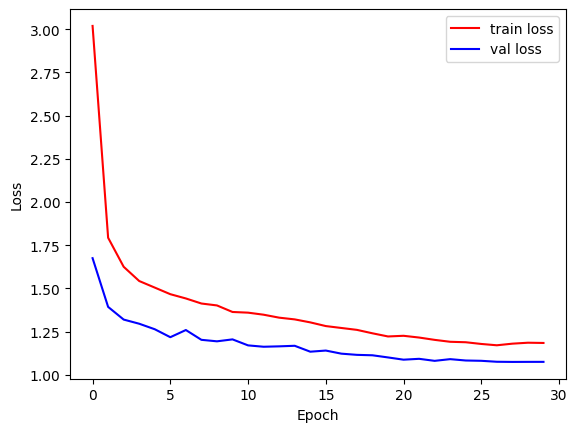

In [10]:
plt.plot(range(num_epochs), train_losses, color="red", label="train loss")
plt.plot(range(num_epochs), val_losses, color="blue", label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

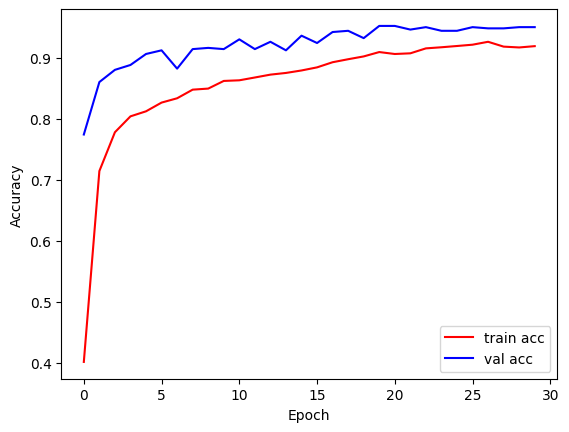

In [11]:
plt.plot(range(num_epochs), train_accuracies, color="red", label="train acc")
plt.plot(range(num_epochs), val_accuracies, color="blue", label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [12]:
y_test = []
y_pred = []

model.eval()

with tc.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.cuda()
        outputs = model(inputs)
        preds = tc.argmax(outputs, dim=1)
        y_test.append(targets)
        y_pred.append(preds)

y_test = tc.cat(y_test).cpu()
y_pred = tc.cat(y_pred).cpu()

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy score: {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Precision score: {:.4f}".format(precision_score(y_test, y_pred, average='weighted')))
print("Recall score: {:.4f}".format(recall_score(y_test, y_pred, average='weighted')))
print("F1 score: {:.4f}".format(f1_score(y_test, y_pred, average='weighted')))

Accuracy score: 0.9500
Precision score: 0.9584
Recall score: 0.9500
F1 score: 0.9484


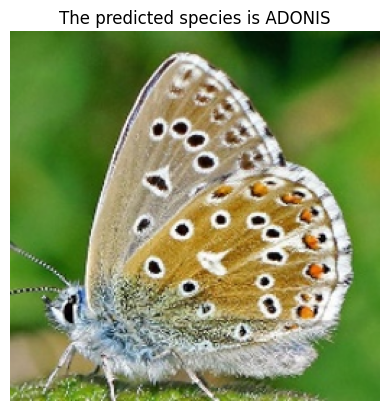

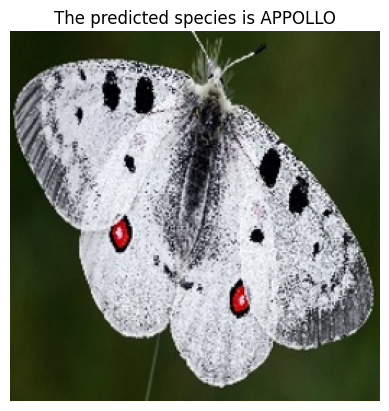

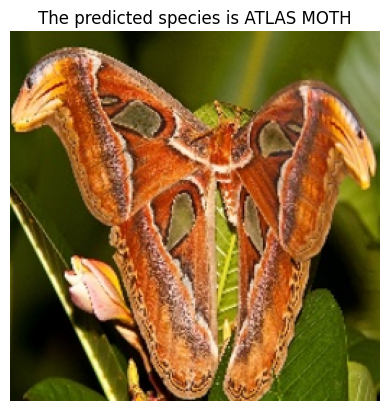

In [14]:
from PIL import Image

image1 = Image.open('/kaggle/input/butterfly-images40-species/test/ADONIS/1.jpg')
image2 = Image.open('/kaggle/input/butterfly-images40-species/test/APPOLLO/1.jpg')
image3 = Image.open('/kaggle/input/butterfly-images40-species/test/ATLAS MOTH/1.jpg')

displayed_image1 = image1.resize((256, 256))
displayed_image2 = image2.resize((256, 256))
displayed_image3 = image3.resize((256, 256))

image1 = test_transform(image1).unsqueeze(0).cuda()
image2 = test_transform(image2).unsqueeze(0).cuda()
image3 = test_transform(image3).unsqueeze(0).cuda()

model.eval()

with tc.no_grad():
    output1 = model(image1)
    output2 = model(image2)
    output3 = model(image3)
    
    prediction1 = tc.argmax(output1, dim=1)
    prediction2 = tc.argmax(output2, dim=1)
    prediction3 = tc.argmax(output3, dim=1)

images = [displayed_image1, displayed_image2, displayed_image3]
predictions = [prediction1, prediction2, prediction3]

for idx, image in enumerate(images):
    plt.figure()
    plt.axis('off')
    plt.imshow(image)
    plt.title('The predicted species is ' + test_loader.dataset.classes[predictions[idx]])

In [15]:
tc.save(model, 'model.pth')